# 📊 Exploratory Data Analysis — Retail Sales Data
### Oasis Infobyte Data Analytics Internship

---

## 1️⃣ Data Loading & Cleaning

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('retail_sales_dataset.csv')
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [9]:
# Check shape and info
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())

(1000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB
None
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64
0


## 2️⃣ Descriptive Statistics

In [10]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


## 3️⃣ Time Series Analysis

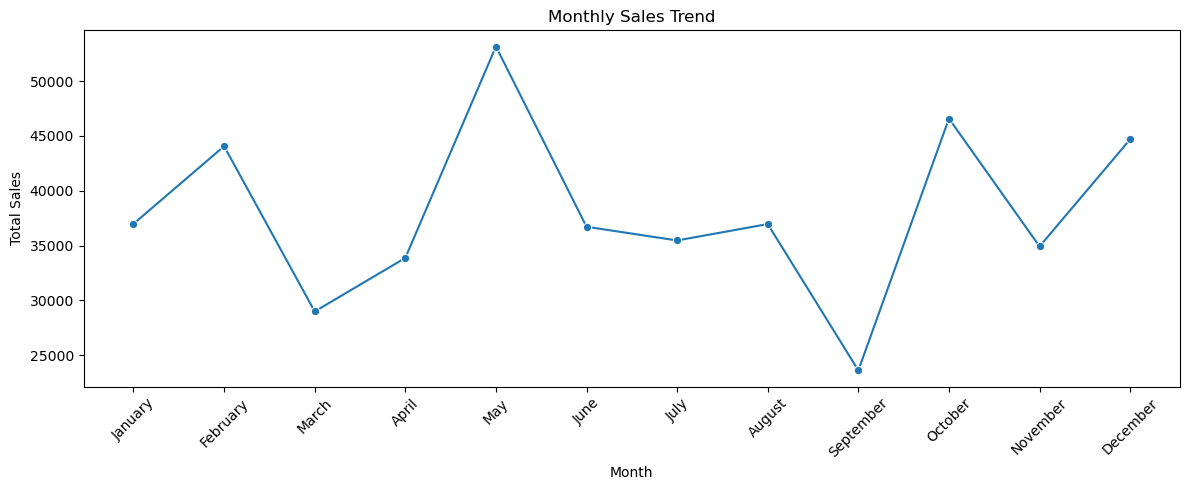

In [11]:
# Ensure Date column is in datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Remove rows where Date could not be converted
df = df.dropna(subset=['Date'])

# Create Month and Year columns
df['Month'] = df['Date'].dt.month_name()
df['Year'] = df['Date'].dt.year

# Correct month order
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

# Monthly sales
monthly_sales = (
    df.groupby('Month')['Total Amount']
    .sum()
    .reindex(month_order)
)

# Plot monthly sales trend
plt.figure(figsize=(12, 5))
sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4️⃣ Customer & Product Analysis

C:\Users\nandi\AppData\Local\Temp\ipykernel_25336\3025311226.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette='Set2')


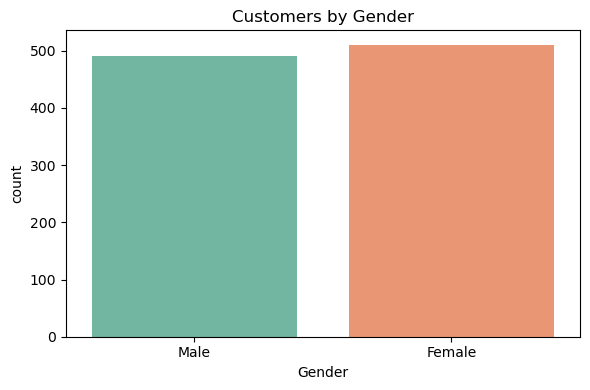

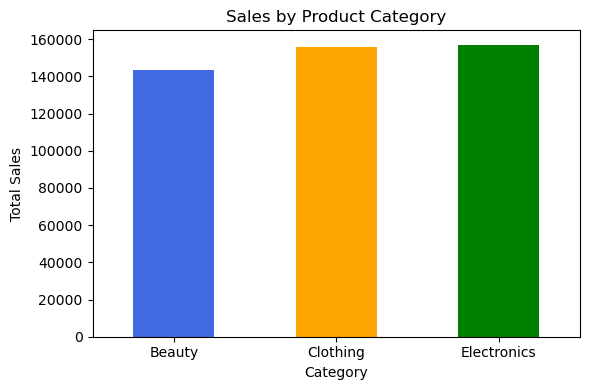

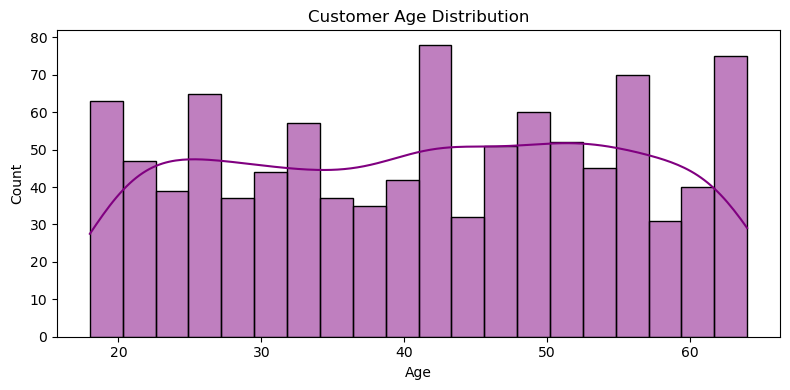

In [12]:
# Sales by Gender
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df, palette='Set2')
plt.title('Customers by Gender')
plt.tight_layout()
plt.show()

# Sales by Product Category
plt.figure(figsize=(6,4))
df.groupby('Product Category')['Total Amount'].sum().plot(kind='bar', color=['royalblue','orange','green'])
plt.title('Sales by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Age Distribution
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], bins=20, kde=True, color='purple')
plt.title('Customer Age Distribution')
plt.tight_layout()
plt.show()

## 5️⃣ Visualization — Heatmap & Top Insights

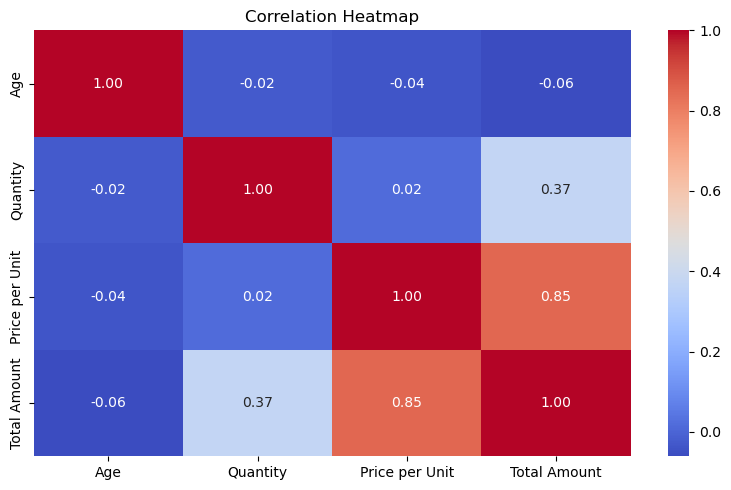

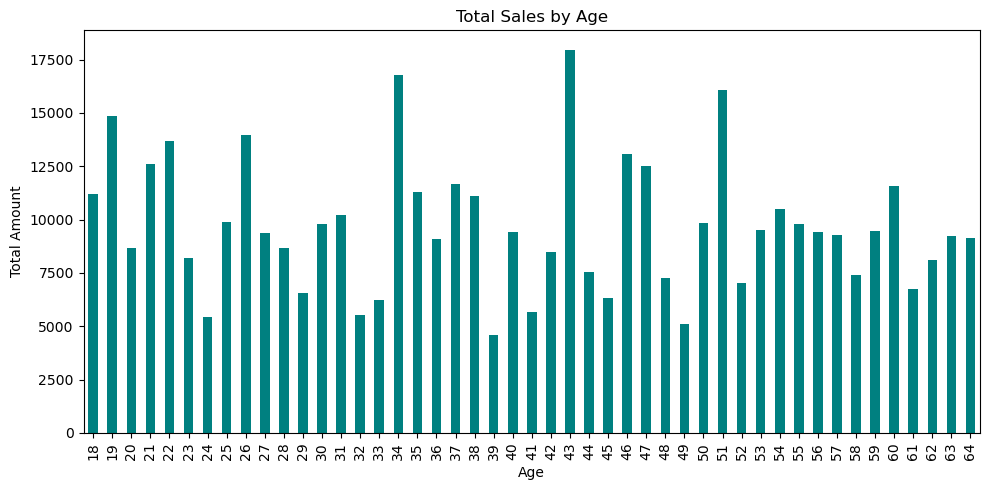

In [13]:
# Heatmap of correlations
plt.figure(figsize=(8,5))
sns.heatmap(df[['Age','Quantity','Price per Unit','Total Amount']].corr(), 
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Top spending age groups
plt.figure(figsize=(10,5))
df.groupby('Age')['Total Amount'].sum().plot(kind='bar', color='teal')
plt.title('Total Sales by Age')
plt.xlabel('Age')
plt.ylabel('Total Amount')
plt.tight_layout()
plt.show()

## 6️⃣ Recommendations
Based on the exploratory data analysis, here are key business insights:

- 📦 **Top Category**: Focus marketing efforts on the best performing product category
- 👥 **Target Age Group**: Customers aged 30-45 spend the most — target them with promotions
- 📅 **Peak Months**: Stock up inventory during high sales months
- 🚻 **Gender**: Both genders shop equally — no need to skew marketing to one gender
- 💰 **Pricing**: Higher priced items drive total revenue — consider premium product lines

## ✅ Conclusion
This EDA revealed key patterns in customer behavior, product performance, and sales trends that can help the retail business make data-driven decisions.